# Load and Explore the Dataset:
<p>The objective of this task is to examine the Fashion MNIST dataset and gain a better understanding of its structure and contents. Begin by importing the dataset and creating a reduced sample consisting of 20% of both the training and testing data. Once the dataset has been loaded, determine and display the dimensions (shape) of the training and test sets for further analysis.</p>

In [163]:

# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np

In [164]:
#Load the Fashion MNIST dataset:

fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train_total, y_train_total), (x_test_total, y_test_total) = fashion_mnist.load_data()

In [165]:
# Import the train and test split function from sklearn:

from sklearn.model_selection import train_test_split

In [166]:
# Extract 20% sample from training and another 20% from test dataset
x_train, _, y_train, _ = train_test_split(x_train_total,
                                          y_train_total,
                                          test_size=0.9,
                                          random_state=1502)


x_test, _, y_test, _ = train_test_split(x_test_total,
                                        y_test_total,
                                        test_size=0.9,
                                        random_state=1502)

In [167]:
# Display the shape of training and testing data

print(f"Training dataset shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing dataset shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training dataset shape: (6000, 28, 28)
Training labels shape: (6000,)
Testing dataset shape: (1000, 28, 28)
Testing labels shape: (1000,)


# Comprehensive Visual Exploration of the Dataset
<div data-purpose="safely-set-inner-html:rich-text-viewer:html" class="lab-rich-text-viewer--lab-html-content--22XsM rt-scaffolding"><p>The Fashion MNIST dataset contains grayscale images representing different types of clothing items and fashion accessories across 10 distinct categories. The goal of this phase is to perform an in-depth visual and statistical exploration of the dataset to better understand its structure, diversity, and class representation before building any machine learning models.:</p><p><strong>Random Sample Visualization:</strong> Select and display one random image from each of the 10 classes, including categories such as T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot. This analysis helps in identifying the visual characteristics, patterns, and similarities between different fashion items while also providing insight into image quality and variation within the dataset.</p><p><strong>Category Distribution Analysis:</strong> Analyze how the images are distributed among the 10 classes by creating a histogram or bar chart of class frequencies. This step is essential for determining whether the dataset is balanced or if certain categories contain significantly more or fewer samples than others. Understanding class distribution is important because imbalanced data can affect the performance and fairness of classification models.</p><p><strong>Dataset Insight and Interpretation: </strong>In addition to visualization, interpret the observed trends and characteristics of the dataset. Highlight any noticeable similarities between categories, potential challenges in classification, and the overall suitability of the dataset for image recognition and deep learning tasks.</p></div>

In [168]:
# Define the class labels of the Fashion MNIST dataset

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

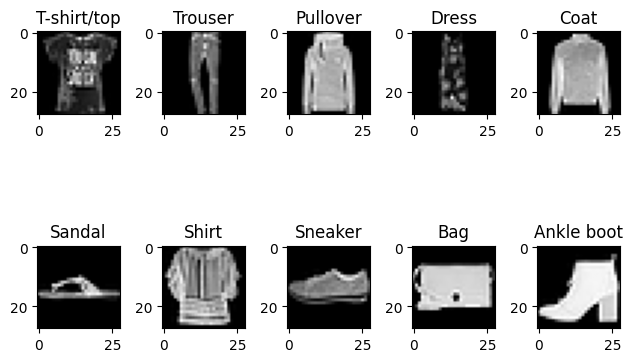

In [169]:
# Display random images from each of the fashion categories

import matplotlib.pyplot as plt

# Loop through each fashion category
for i in range(10):
    # Randomly select an image index corresponding to the current fashion category
    idx = np.random.choice(np.where(y_train == i)[0])

    # Plot the image
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
plt.tight_layout()
plt.show()


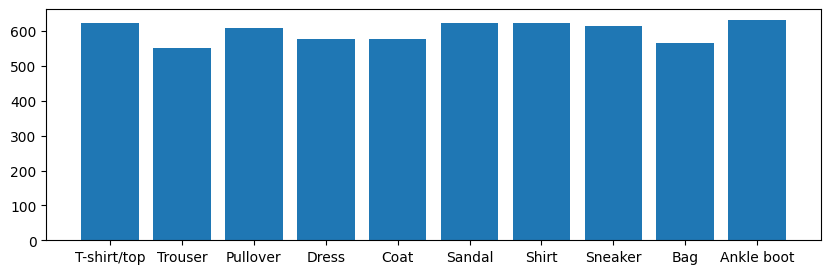

In [170]:
# Visualize the distribution of fashion categories in the dataset

# Display the count of images per fashion category
plt.figure(figsize=(10,3))
plt.hist(y_train, bins=np.arange(11)-0.5, rwidth=0.8)
plt.xticks(np.arange(10), class_names)
plt.show()

# Preprocessing the Dataset for Improved Neural Network Performance
<p>The main objective of this stage is to prepare and optimize the Fashion MNIST dataset for effective deep learning and image classification tasks. Proper preprocessing is an essential step in machine learning because it improves data quality, enhances model performance, and ensures compatibility with neural network architectures.</p>

<p>The first step involves normalizing the grayscale pixel values of the images. Since the original pixel intensities range from 0 to 255, they are scaled down to a range between 0 and 1. This normalization process helps the neural network train more efficiently by reducing large numerical variations, improving convergence speed, and enhancing overall model stability during training.<p>

<p>After normalization, the dataset is reshaped by adding an additional channel dimension to each image. Although Fashion MNIST images are grayscale and contain only one color channel, Convolutional Neural Networks (CNNs) still expect image data in a structured multi-dimensional tensor format. Adding this channel dimension ensures that the dataset matches the input requirements of CNN layers and allows the model to process spatial image features correctly.</p>

<p>Furthermore, these preprocessing steps contribute to faster computation, reduced training complexity, and improved accuracy in pattern recognition tasks. By transforming the dataset into a neural network-friendly format, the model becomes better equipped to learn meaningful visual features from the fashion images and achieve reliable classification performance.</p>

In [171]:
# Normalize the training and testing datasets:

x_train = x_train / 255.0
x_test = x_test / 255.0

In [172]:
# Adjust the shape of datasets to include the channel dimension:

# Alter the data shape to following (number of samples, height, width, number of channels)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# Image Data Augmentation to Improve Model Performance
<div data-purpose="safely-set-inner-html:rich-text-viewer:html" class="lab-rich-text-viewer--lab-html-content--22XsM rt-scaffolding"><p>The objective of this stage is to enhance the robustness and generalization ability of the deep learning model by artificially expanding the training dataset using image augmentation techniques. This helps the model perform better on unseen data by exposing it to a wider variety of image transformations and preventing overfitting.</p><p>To achieve this, data augmentation is applied using TensorFlow’s <code><strong>ImageDataGenerator</strong></code>. This tool generates modified versions of existing images in real time during training, allowing the model to learn from slightly altered inputs without increasing the actual dataset size.</p><p>The augmentation process includes several controlled transformations:</p><ul><li><p><strong>Small rotations</strong>  of up to 10 degrees to simulate slight orientation changes</p></li><li><p><strong>Zoom variations</strong> within a range of 10% to mimic differences in object scale</p></li><li><p><strong>Shearing</strong> with a factor of 0.1 to introduce subtle geometric distortion</p></li><li><p><strong>Horizontal and vertical shifts</strong>  of up to 10% to simulate positional changes within the frame</p></li><li><strong>Horizontal flipping</strong>  to increase variability in object orientation</p></li></ul><p>By incorporating these transformations, the model becomes more adaptable to real-world variations in fashion images, ultimately improving its accuracy, stability, and ability to generalize beyond the training dataset.</p></div>

In [173]:


# Initialize the ImageDataGenerator with the desired augmentations
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
   rotation_range=10,      # Rotate images up to 10 degrees
   zoom_range=0.1,         # Zoom in on images up to 10%
   shear_range=0.1,        # Shear images by a factor of 0.1
   width_shift_range=0.1,  # Shift the width of images up to 10%
   height_shift_range=0.1, # Shift the height of images up to 10%
   horizontal_flip=True    # Allow horizontal flipping of images
)

In [174]:
# Implement the defined augmentations to the main training dataset.

datagen.fit(x_train)

# Designing and Training a Convolutional Neural Network for Fashion Image Classification
<div data-purpose="safely-set-inner-html:rich-text-viewer:html" class="lab-rich-text-viewer--lab-html-content--22XsM rt-scaffolding"><p>The goal of this stage is to build, compile, and train a Convolutional Neural Network (CNN) to accurately classify images from the Fashion MNIST dataset. The model is designed in a layered architecture to progressively extract and learn meaningful visual features from input images.</P>

<p>The network begins with a convolutional layer containing 32 filters with a 3×3 kernel and ReLU activation, followed by a 2×2 max pooling layer to reduce spatial dimensions. To reduce overfitting, a dropout layer with a 20% rate is applied.<p>

<p>Next, a second convolutional layer with 64 filters and a 3×3 kernel is added, again using ReLU activation to capture deeper and more complex patterns. This is followed by another 2×2 pooling layer and a second dropout layer with a 20% rate for regularization.</p><p>The extracted features are then flattened into a one-dimensional vector and passed through a fully connected dense layer consisting of 256 neurons with ReLU activation. A higher dropout rate of 50% is applied at this stage to further improve generalization.</p>

<p>Finally, the output layer contains 10 neurons with softmax activation to classify the input image into one of the 10 fashion categories.</p><ul><li><p><strong>Initial Convolutional Layer</strong>: 32 filters, a 3x3 kernel, and 'relu' activation.</p></li><li><p><strong>Pooling Layer</strong>: A 2x2 pooling matrix.</p></li><li><p><strong>Dropout Layer</strong>: 20% dropout rate.</p></li><li><p><strong>Second Convolutional Layer</strong>: 64 filters, a 3x3 kernel, and 'relu' activation.</p></li><li><p><strong>Second Pooling Layer</strong>: A 2x2 pooling matrix.</p></li><li><p><strong>Dropout Layer</strong>: 20% dropout rate.</p></li><li><p><strong>Flattening Layer</strong>.</p></li><li><p><strong>Dense Layer</strong>: 256 units with 'relu' activation.</p></li><li><p><strong>Dropout Layer</strong>: 50% dropout rate.</p></li><li><p><strong>Final Dense Layer</strong>: 10 units with 'softmax' activation.</p></li></ul><p>The model is compiled using the Adam optimizer, with sparse categorical cross-entropy as the loss function and accuracy as the evaluation metric. Training is performed for 5 epochs with a batch size of 32, using augmented training data while validating performance on the test dataset to assess generalization capability.</p><p><br></p></div>

In [175]:


# Importing required modules from TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [176]:


# Defining the CNN architecture with the provided specifications
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),  # First convolutional layer
    MaxPooling2D(2, 2),                                             # First pooling layer
    Dropout(0.2),                                                   # 20% dropout layer
    Conv2D(64, (3,3), activation='relu'),                           # Second convolutional layer
    MaxPooling2D(2, 2),                                             # Second pooling layer
    Dropout(0.2),                                                   # 20% dropout layer
    Flatten(),                                                      # Flattening layer
    Dense(256, activation='relu'),                                  # Dense layer with 256 units
    Dropout(0.5),                                                   # 50% dropout layer
    Dense(10, activation='softmax')                                 # Output layer with 10 units
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [177]:
# Compile the CNN model with the appropriate parameters.


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [178]:


# Training the model with augmented data and validating on the test set
history = model.fit(datagen.flow(x_train,
                                 y_train,
                                 batch_size=32),
                    epochs=5,
                    validation_data=(x_test,
                                     y_test))


Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.4938 - loss: 1.3424 - val_accuracy: 0.6690 - val_loss: 0.8151
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6688 - loss: 0.8961 - val_accuracy: 0.7140 - val_loss: 0.7186
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.6848 - loss: 0.8299 - val_accuracy: 0.7350 - val_loss: 0.6570
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7057 - loss: 0.7690 - val_accuracy: 0.7390 - val_loss: 0.6164
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7243 - loss: 0.7326 - val_accuracy: 0.7590 - val_loss: 0.5904


# Optimizing CNN Training Using Advanced Callback Techniques
<div data-purpose="safely-set-inner-html:rich-text-viewer:html" class="lab-rich-text-viewer--lab-html-content--22XsM rt-scaffolding"><p>The objective of this phase is to enhance the training efficiency and performance of the previously developed Convolutional Neural Network by incorporating advanced optimization strategies. These techniques are designed to improve model convergence, prevent overfitting, and ensure better generalization on unseen data.</p><ul><li><p>To achieve this, an <strong>early stopping</strong> mechanism is implemented that continuously monitors the validation accuracy (val_accuracy). If the model does not show any improvement for 5 consecutive epochs, the training process is automatically terminated to avoid unnecessary computation and overfitting.</p></li><li><p>In addition, a <strong>learning rate scheduling</strong> strategy is introduced to control the pace of learning during training. The learning rate is kept unchanged for the first 10 epochs to allow stable initial convergence. After the 10th epoch, it is reduced by a factor of 0.1 to enable finer weight updates and improved model refinement in later stages.</p></li></ul><p>The model is trained for a maximum of 20 epochs, but the actual training duration may vary depending on the early stopping condition. These combined strategies ensure efficient training, reduced overfitting risk, and improved overall model performance.</p><p><br></p></div>

In [179]:


# Implementing early stopping based on validation accuracy
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=5)


In [180]:
# Define the custom learning rate scheduler function.


def lr_schedule(epoch, lr):
    if epoch > 10:
        return lr * 0.1  # Reduce learning rate by a factor of 0.1 after 10 epochs
    return lr


In [181]:


# Initializing the learning rate scheduler callback
scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

In [182]:


# Training the CNN model with augmented data, using the callbacks for early stopping and learning rate scheduling
history = model.fit(datagen.flow(x_train,
                                 y_train,
                                 batch_size=32),
                    epochs=20,
                    validation_data=(x_test,
                                     y_test),
                    callbacks=[early_stop, scheduler])

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7300 - loss: 0.7034 - val_accuracy: 0.7540 - val_loss: 0.5776 - learning_rate: 0.0010
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7302 - loss: 0.6898 - val_accuracy: 0.7620 - val_loss: 0.5779 - learning_rate: 0.0010
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7347 - loss: 0.6787 - val_accuracy: 0.7710 - val_loss: 0.5718 - learning_rate: 0.0010
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7413 - loss: 0.6567 - val_accuracy: 0.7900 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.7513 - loss: 0.6377 - val_accuracy: 0.7810 - val_loss: 0.5269 - learning_rate: 0.0010
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.7558 - loss: 0.6269 - val_accuracy: 0.7830 - val_loss: 0.5221 - learning_rate: 0.0010
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7590 - loss

# Model Evaluation and Analysis of Classification Errors
<div data-purpose="safely-set-inner-html:rich-text-viewer:html" class="lab-rich-text-viewer--lab-html-content--22XsM rt-scaffolding"><p>The objective of this stage is to assess the performance of the trained Convolutional Neural Network and gain deeper insights into its learning behavior and prediction quality. This evaluation helps determine how well the model generalizes to unseen data and identifies areas where it may be misclassifying inputs.</p><ul><li><p>To begin with, the training and testing accuracy trends are plotted to observe how model performance improves over time and to check for signs of overfitting or underfitting. In a similar manner, loss curves for both datasets are visualized to understand how effectively the model is minimizing prediction errors during training.</p></li><li><p>Further, a confusion matrix is generated for the test dataset to compare actual class labels with the model’s predicted outputs. This provides a detailed breakdown of correct and incorrect classifications across all categories.

</p></li><li><p>Finally, the confusion matrix is visualized to clearly highlight patterns of misclassification, making it easier to identify which classes are frequently confused by the model. These evaluation steps collectively provide a comprehensive understanding of model accuracy, reliability, and class-wise performance.</p></li></ul></div>

In [183]:
# Start by importing necessary visualization and matrix evaluation libraries.

from sklearn.metrics import confusion_matrix
import seaborn as sns


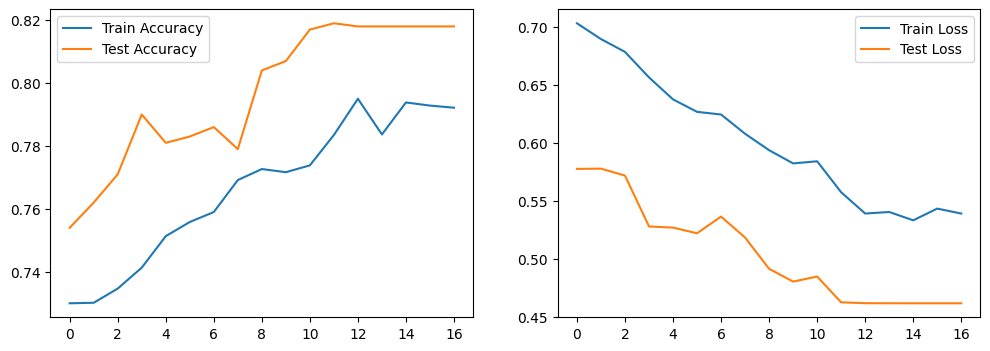

In [184]:
# Plot the accuracy curves for both the training and testing data to evaluate the model's performance during training epochs. Use a similar approach to visualize how the model's loss has changed over the training epochs.

# Setting up the figure for plotting
plt.figure(figsize=(12, 4))

# Plotting the accuracy curve for training and testing data
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()

# Plotting the loss curve for training and testing data
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()

# Displaying the accuracy plot
plt.show()

In [185]:
# Generate a confusion matrix using the true labels from the test data and the predicted labels from the model.

# Predicting labels for the testing dataset
y_pred = model.predict(x_test)

# Generating the confusion matrix
cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


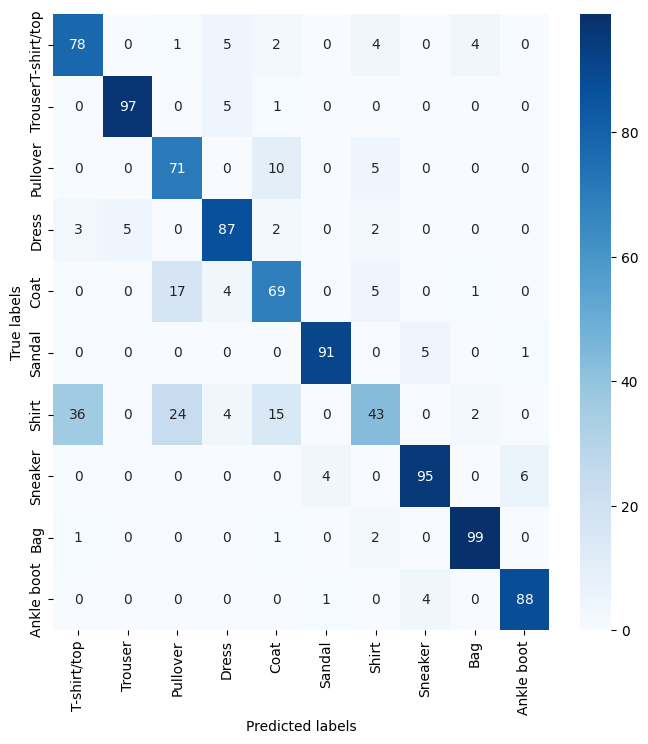

In [186]:
# Utilize a heatmap to visually present the confusion matrix, ensuring to include annotations for clarity.

# Setting up the figure for the heatmap
plt.figure(figsize=(8,8))

# Visualizing the confusion matrix using a heatmap
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

# Displaying the confusion matrix plot
plt.show()

# Developing a Grad-CAM Based Visualization for Model Interpretability

<p>The objective of this task is to design and implement a function named <code><strong>make_gradcam_heatmap</strong></code>, that generates a Grad-CAM (Gradient-weighted Class Activation Mapping) heatmap for a trained deep learning model. This technique provides a visual explanation of model predictions by highlighting the regions of an input image that contribute most strongly to the final decision.

</p><p> The resulting heatmap overlays important activation areas onto the original image, allowing users to understand which spatial features the model focuses on during classification. This improves the transparency and interpretability of deep neural networks, especially in scenarios where explaining model decisions is important.</p>

<p>By using this approach, the internal behavior of the model becomes more understandable, making it easier to validate predictions, build trust in the system, and identify potential biases or misinterpretations in learned patterns.</p>

In [187]:

# Acquire the desired convolutional layer from the model and construct a new model that maps the original input to this layer's activations.
# Determine the index or position of our target layer within the model's architecture.
# Establish a separate model that processes the activations of our target layer and yields the model's ultimate class predictions.
# Utilize TensorFlow's gradient tracking mechanism to monitor the activations and compute the classification scores.
# Compute the gradient that represents the importance of each feature in the convolutional layer's activations with respect to the target class score.
# Generate the heatmap by weighing the activations by their respective importance, and then normalize it to ensure values lie between 0 and 1.


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate a GradCAM heatmap for a given image array.

    Args:
    - img_array (numpy.ndarray): The input image array.
    - model (tf.keras.Model): The pre-trained model.
    - last_conv_layer_name (str): The name of the last convolutional layer in the model.
    - pred_index (int, optional): The index of the prediction class. Uses top prediction if None.

    Returns:
    - numpy.ndarray: The GradCAM heatmap.
    """
    # Obtain the last convolutional layer from the model
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Create a model that maps the model's input to the last_conv_layer's output
    last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)


    # Get the index of the specified convolutional layer in the model
    last_conv_layer_idx = [layer.name for layer in model.layers].index(last_conv_layer_name)


    # Create an input placeholder with the shape of the output from last_conv_layer
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    # Loop through layers after the last_conv_layer and build the classifier model
    for layer in model.layers[last_conv_layer_idx+1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    # Set up the GradientTape for automatic differentiation
    with tf.GradientTape() as tape:
        # Compute the activations of the last convolutional layer
        last_conv_layer_output = last_conv_layer_model(img_array)
        # Make sure TensorFlow watches this output for gradient calculations
        tape.watch(last_conv_layer_output)
        # Predict the class scores using the classifier model
        preds = classifier_model(last_conv_layer_output)
        # If no specific class index is provided, use the class with the highest score
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        # Extract the score for the target class
        class_channel = preds[:, pred_index]

    # Calculate the gradient of the target class score with respect to the activations
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Average the gradients spatially (over height and width) to get the importance of each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


    # Weigh the activations by the importance to get the heatmap
    last_conv_layer_output = last_conv_layer_output * pooled_grads[tf.newaxis, tf.newaxis, tf.newaxis, :]

    # Average over the feature maps to get a 2D heatmap
    heatmap = tf.reduce_mean(last_conv_layer_output, axis=-1)[0]

    # Normalize the heatmap to lie between 0 and 1
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap


# Visualizing Model Attention Using Grad-CAM on a Random Test Image
<p>The objective of this task is to generate and display a Grad-CAM (Gradient-weighted Class Activation Mapping) visualization for a randomly selected image from the test dataset <code><strong>x_test</strong></code>. using a trained deep learning model. This technique provides an intuitive way to interpret the model’s prediction by highlighting the specific regions of the image that contributed most to its decision-making process.</p><p>By overlaying the Grad-CAM heatmap onto the original image, we can clearly observe where the neural network is “looking” while making its prediction. This helps in understanding the internal focus of the model and provides valuable insights into how different spatial regions influence classification outcomes.</p></p><p>Such visual explanations improve model transparency, making it easier to validate predictions and assess whether the model is learning meaningful and relevant features from the input data.</p>

In [209]:


# Display all layers in the model and their names
for layer in model.layers:
    print(layer.name)

conv2d_12
max_pooling2d_12
dropout_18
conv2d_13
max_pooling2d_13
dropout_19
flatten_6
dense_12
dropout_20
dense_13


In [210]:
# Randomly select an image from test dataset.

img_array = x_test[np.random.choice(x_test.shape[0])]

# Reshape the image to add an extra dimension for batch size
img_array = img_array[np.newaxis, :]


In [211]:
# Predict the class of the chosen image.

# Get the model's predictions for the selected image
preds = model.predict(img_array)

# Determine the index of the class with the highest prediction score
top_pred_index = np.argmax(preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [212]:
# Use the make_gradcam_heatmap function to produce the heatmap.

# Generate the GradCAM heatmap for the image based on the specified layer and prediction
heatmap = make_gradcam_heatmap(img_array, model, 'conv2d_13', top_pred_index)


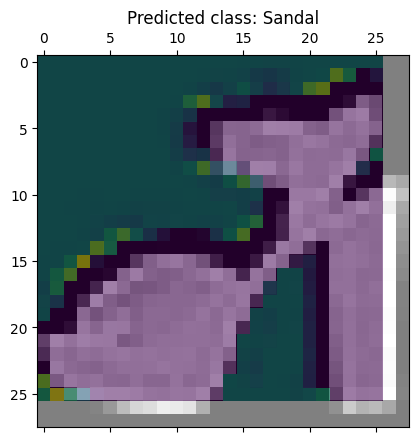

In [213]:
# Visualize the heatmap and the original image together.

# Display the heatmap
plt.matshow(heatmap)

# Overlay the original image and heatmap
plt.imshow(img_array.reshape(28, 28), cmap='gray', alpha=0.5)

# Title the visualization with the model's top prediction
plt.title(f"Predicted class: {class_names[top_pred_index]}")

plt.show()


# Model Saving, Loading, and Deployment Demonstration

<p>In this final stage of the project, the focus is on preserving the trained neural network and demonstrating its practical usability. The trained model should first be saved in a standard format that securely stores both its architecture and learned weights, ensuring it can be reused without retraining.</p><p> After saving, the model is loaded back into the working environment to confirm successful restoration and integrity. Once reloaded, its performance is tested by selecting a random image from the test dataset and generating a prediction using the model.</p><p>

The predicted output is then visually displayed alongside the selected image to clearly show the classification result. This step serves as a simple deployment simulation, validating that the model functions correctly outside the training environment and is ready for real-world application.</p>

In [214]:
# Begin by saving the model in the native Keras format.

# Save the model
model.save("cnn_model.keras")


In [215]:
# Load the saved model back into the environment.

# Load the model
loaded_model = tf.keras.models.load_model("cnn_model.keras")


In [216]:
# Randomly select an image from the test dataset x_test.

# Predict on a random test image
random_idx = np.random.choice(len(x_test))
test_img = x_test[random_idx]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


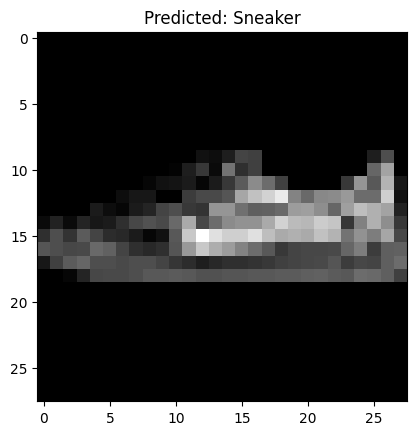

In [217]:
# Display the chosen image and overlay with the model's predicted class.

# Display the selected image
plt.imshow(test_img.reshape(28, 28), cmap='gray')

# Predict the class of the image using the loaded model
predictions = loaded_model.predict(test_img.reshape(1, 28, 28, 1))
predicted_class = np.argmax(predictions)

# Add the predicted class as the title
plt.title(f"Predicted: {class_names[predicted_class]}")

# Show the image with the prediction
plt.show()

# Deploying the Model on Streamlit

<p>In this section, we deploy the trained TensorFlow CNN image classification model as an interactive Streamlit web application directly from Google Colab using Ngrok tunneling.

The deployment includes:<ul>
<li>Creating a Streamlit application</li>
<li>Loading the trained `.keras` model</li>
<li>Uploading and predicting images in real-time</li>
<li>Generating a public URL using Ngrok</li></ul>

</p>


In [233]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# ------------------------------
# Page Configuration
# ------------------------------
st.set_page_config(
    page_title="Fashion MNIST Classifier",
    page_icon="👕",
    layout="centered"
)

# ------------------------------
# Load Model
# ------------------------------
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("cnn_model.keras")
    return model

model = load_model()

# ------------------------------
# Class Labels
# ------------------------------
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# ------------------------------
# Title
# ------------------------------
st.title("👕 Fashion MNIST Image Classification (28x28 preferred)")

st.write(
    "Upload a grayscale fashion image (28x28 preferred) and the CNN model will predict the clothing category."
)

# ------------------------------
# File Upload
# ------------------------------
uploaded_file = st.file_uploader(
    "Upload an image",
    type=["jpg", "jpeg", "png"]
)

# ------------------------------
# Prediction Logic
# ------------------------------
if uploaded_file is not None:

    # Open image
    image = Image.open(uploaded_file).convert("L")

    # Resize image
    image = image.resize((28, 28))

    # Display image
    st.image(image, caption="Uploaded Image", width=200)

    # Convert image to numpy array
    img_array = np.array(image)

    # Normalize
    img_array = img_array / 255.0

    # Reshape for CNN
    img_array = img_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(img_array)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Show prediction
    st.subheader("Prediction Result")

    st.success(
        f"Predicted Class: {class_names[predicted_class]}"
    )

    st.info(
        f"Confidence Score: {confidence:.2f}%"
    )

    # Show all class probabilities
    st.subheader("Class Probabilities")

    for idx, class_name in enumerate(class_names):
        st.write(
            f"{class_name}: {prediction[0][idx] * 100:.2f}%"
        )

Overwriting app.py


In [234]:
import getpass
from pyngrok import ngrok

token = getpass.getpass("Enter your ngrok token: ")

ngrok.set_auth_token(token)

Enter your ngrok token: ··········


In [235]:
from pyngrok import ngrok
import threading
import os

ngrok.kill()

def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit)
thread.start()

In [236]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://plot-cotton-fried.ngrok-free.dev" -> "http://localhost:8501"
